# 03 - Modelado Supervisado
## Prediccion de produccion de petroleo (Vaca Muerta / YPF)

**Objetivo:** predecir cuanto petroleo (`prod_pet`) va a producir un pozo en un
mes dado, usando como pistas: cuanto produjo el mes anterior, la antiguedad
del pozo, la profundidad, la formacion y la cuenca.

**Como evaluamos:** separamos los datos por tiempo (no al azar), para simular
una situacion real: entrenamos con anios viejos y probamos con anios nuevos
que el modelo nunca vio.

In [1]:
import sys
import os

sys.path.append("..")

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Carpeta de trabajo actual:", os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

sns.set_theme(style="whitegrid")
%matplotlib inline

Carpeta de trabajo actual: /Users/cristianaguilera/Desktop/proyecto-final-data-science


## Paso 1: Cargar el dataset con las variables ya creadas

Este archivo lo generamos en el notebook 02, ya tiene todas las columnas
nuevas (antiguedad, lag, declinacion, ratio, acumulada, codigos).

In [2]:
df = pd.read_csv("data/processed/produccion_con_features.csv")
print(df.shape)
df.head()

(421046, 49)


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,antiguedad_meses,prod_pet_mes_anterior,prod_gas_mes_anterior,declinacion_pet,declinacion_gas,ratio_gas_petroleo,prod_pet_acumulada,prod_gas_acumulada,formacion_cod,cuenca_cod
0,PEL,2006,2,3640,0.000,0.000,0.000,0.0,0.0,0.0,...,1,NaN,NaN,NaN,NaN,NaN,0.000,0.000,27,2
1,PEL,2006,3,3640,30.808,1.731,30.570,0.0,0.0,0.0,...,2,0.000,0.000,NaN,NaN,0.056187,30.808,1.731,27,2
2,PEL,2006,4,3640,76.609,3.713,46.479,0.0,0.0,0.0,...,3,30.808,1.731,1.486659,1.145003,0.048467,107.417,5.444,27,2
3,PEL,2006,5,3640,63.273,4.202,50.536,0.0,0.0,0.0,...,4,76.609,3.713,-0.174079,0.131699,0.066411,170.690,9.646,27,2
4,PEL,2006,6,3640,55.043,4.373,52.062,0.0,0.0,0.0,...,5,63.273,4.202,-0.130071,0.040695,0.079447,225.733,14.019,27,2


## Paso 1.5: Cuidado con la fuga de datos (data leakage)

`declinacion_pet` se calcula asi: `(prod_pet - prod_pet_mes_anterior) / prod_pet_mes_anterior`

El problema: `prod_pet` (lo que queremos predecir) esta adentro de esa formula.
Si el modelo recibe `prod_pet_mes_anterior` y `declinacion_pet` juntos, puede
"despejar" el resultado exacto con una simple cuenta - no esta prediciendo
de verdad, esta recibiendo la respuesta disfrazada.

**La solucion:** usar la declinacion del mes ANTERIOR (no la de este mes),
que es un dato que si conocemos al momento de predecir.

In [3]:
df = df.sort_values(["idpozo", "anio", "mes"]).reset_index(drop=True)

# declinacion_pet_anterior = como veniamos declinando HASTA el mes pasado
# (no incluye el mes que queremos predecir, por eso no es fuga de datos)
df["declinacion_pet_anterior"] = df.groupby("idpozo")["declinacion_pet"].shift(1)

df[["idpozo", "anio", "mes", "declinacion_pet", "declinacion_pet_anterior"]].head(10)

,idpozo,anio,mes,declinacion_pet,declinacion_pet_anterior
0,3640,2006,2,NaN,NaN
1,3640,2006,3,NaN,NaN
2,3640,2006,4,1.486659,NaN
3,3640,2006,5,-0.174079,1.486659
4,3640,2006,6,-0.130071,-0.174079
5,3640,2006,7,0.069382,-0.130071
6,3640,2006,8,-0.435272,0.069382
7,3640,2006,9,0.121747,-0.435272
8,3640,2006,10,0.720822,0.121747
9,3640,2006,11,-0.020400,0.720822


## Paso 1.6: Nueva variable para ayudar con los picos altos

El modelo viene subestimando los pozos con picos de produccion muy altos
(posibles reestimulaciones/refracturas). La hipotesis: si un pozo YA
demostro en el pasado que puede producir mucho, es mas probable que
vuelva a tener un pico. Creamos una variable con el maximo historico de
produccion de cada pozo, calculado SOLO con datos hasta el mes anterior
(shift antes de calcular el maximo, para no usar el dato del mes que
queremos predecir - no es fuga de datos).

In [4]:
# Primero corremos el maximo un mes hacia atras (shift), y RECIEN despues
# calculamos el maximo acumulado - asi el maximo de la fila actual nunca
# incluye la produccion de ese mismo mes.
df["prod_pet_mes_anterior_shift"] = df.groupby("idpozo")["prod_pet"].shift(1)
df["prod_pet_maxima_anterior"] = df.groupby("idpozo")["prod_pet_mes_anterior_shift"].cummax()
df = df.drop(columns=["prod_pet_mes_anterior_shift"])

df[["idpozo", "anio", "mes", "prod_pet", "prod_pet_maxima_anterior"]].head(10)

,idpozo,anio,mes,prod_pet,prod_pet_maxima_anterior
0,3640,2006,2,0.000,NaN
1,3640,2006,3,30.808,0.000
2,3640,2006,4,76.609,30.808
3,3640,2006,5,63.273,76.609
4,3640,2006,6,55.043,76.609
5,3640,2006,7,58.862,76.609
6,3640,2006,8,33.241,76.609
7,3640,2006,9,37.288,76.609
8,3640,2006,10,64.166,76.609
9,3640,2006,11,62.857,76.609


## Paso 2: Elegir las columnas que va a usar el modelo

`X` son las pistas (features) que le damos al modelo.
`y` es lo que queremos predecir (la produccion de petroleo de ese mes).

**Ajuste que se mantiene:**
- `declinacion_pet_anterior` (declinacion del mes PASADO, sin fuga de datos - Paso 1.5)

**Ajuste probado y descartado:** `prod_pet_maxima_anterior` (Paso 1.6) se
probo pero no mejoro el modelo (ver tabla comparativa mas abajo) - se
calcula igual en el notebook para dejarlo documentado, pero no se incluye
en la lista final de features, para no sumar complejidad sin beneficio.

In [5]:
columnas_features = [
    "antiguedad_meses",
    "prod_pet_mes_anterior",
    "prod_gas_mes_anterior",
    "declinacion_pet_anterior",
    "ratio_gas_petroleo",
    "profundidad",
    "formacion_cod",
    "cuenca_cod",
]
columna_objetivo = "prod_pet"

print("Features:", columnas_features)
print("Objetivo:", columna_objetivo)

Features: ['antiguedad_meses', 'prod_pet_mes_anterior', 'prod_gas_mes_anterior', 'declinacion_pet_anterior', 'ratio_gas_petroleo', 'profundidad', 'formacion_cod', 'cuenca_cod']
Objetivo: prod_pet


## Paso 3: Sacar las filas que no sirven para entrenar

- El primer mes de cada pozo no tiene "mes anterior", asi que esa fila
  queda con NaN y no se puede usar para entrenar.
- El anio 2026 esta incompleto (lo marcamos en el preprocesamiento), asi
  que tampoco lo usamos todavia.

In [6]:
df_modelo = df[df["anio_completo"]].copy()
df_modelo = df_modelo.dropna(subset=columnas_features + [columna_objetivo])

print("Filas antes de filtrar:", len(df))
print("Filas listas para entrenar:", len(df_modelo))

Filas antes de filtrar: 421046
Filas listas para entrenar: 234267


## Paso 4: Separar en entrenamiento (train) y prueba (test) por anio

En vez de mezclar todo al azar, usamos anios viejos para entrenar y
anios nuevos para probar - asi simulamos una situacion real, donde el
modelo tiene que predecir el futuro, no el pasado.

In [7]:
anio_corte = 2024  # entrenamos con todo lo anterior a este anio

train = df_modelo[df_modelo["anio"] < anio_corte]
test = df_modelo[df_modelo["anio"] >= anio_corte]

X_train = train[columnas_features]
y_train = train[columna_objetivo]

X_test = test[columnas_features]
y_test = test[columna_objetivo]

print("Filas de entrenamiento:", len(X_train))
print("Filas de prueba:", len(X_test))

Filas de entrenamiento: 169097
Filas de prueba: 65170


## Paso 5: Entrenar el modelo

Usamos XGBoost, un modelo de tipo "arbol de decision" muy usado para
este tipo de problemas (datos en tabla, con relaciones no lineales).

**Se probo entrenar sobre `log(1 + prod_pet)`** en vez del valor directo,
buscando que los picos altos pesen mas durante el entrenamiento. El
resultado fue PEOR (R2 bajo a 0.854, el error en picos subio a 6028.6) -
el problema es que un error chico en escala logaritmica se convierte en
un error gigante al revertirlo (el grafico de real vs predicho mostro
predicciones desbocadas hasta 35.000 para pozos que producian 7.000-10.000).
Se descarta esa idea y se entrena directo sobre `prod_pet`, como en la
version v1/v2 (ver tabla comparativa mas abajo).

In [8]:
modelo = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
)

modelo.fit(X_train, y_train)
print("Modelo entrenado")

Modelo entrenado


## Paso 6: Ver que tan bien predice

Le pedimos al modelo que prediga sobre los datos de prueba (que nunca vio)
y comparamos con los valores reales usando tres metricas:

- **MAE** (error promedio en las mismas unidades que `prod_pet`, mas facil de interpretar)
- **RMSE** (parecido al MAE, pero castiga mas fuerte los errores grandes)
- **R2** (que tan bien explica el modelo la variacion de los datos, de 0 a 1, mas cerca de 1 es mejor)

In [9]:
predicciones = modelo.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.3f}")

MAE:  163.33
RMSE: 445.42
R2:   0.885


### Comparacion con las versiones anteriores

- **Base (7 features):** el primero que entrenamos, sin variables de declinacion.
- **Con fuga (DESCARTADO):** R2 de 0.978, pero por fuga de datos (ver Paso 1.5).
- **+ maxima historica (DESCARTADO):** se probo `prod_pet_maxima_anterior`
  como novena feature - resultado practicamente identico (R2 0.885, misma
  MAE/RMSE), sin aporte real. Se descarta por no sumar valor.
- **Log-transform (DESCARTADO):** entrenar sobre `log(1+prod_pet)` empeoro
  todo (R2 bajo a 0.854, RMSE subio a 501.67, picos con error de 6028.6) -
  un error chico en escala logaritmica se amplifica mucho al revertirlo
  (se vieron predicciones de hasta 35.000 para pozos que producian
  7.000-10.000 reales). Se descarta por generar sobreestimaciones extremas.
- **Modelo final (8 features):** el que corre este notebook - `declinacion_pet_anterior`
  agregada al modelo base, entrenado directo sobre `prod_pet` (sin log,
  sin maxima historica). Es la mejor combinacion de metricas con la menor
  complejidad de las 5 versiones probadas.

In [10]:
# Resultados de todas las versiones probadas, documentados para el informe
mae_base, rmse_base, r2_base = 195.11, 520.31, 0.853
mae_leak, rmse_leak, r2_leak = 38.86, 204.07, 0.978  # descartado por fuga de datos
mae_maxima, rmse_maxima, r2_maxima = 165.63, 444.47, 0.885  # descartado, no aporto
mae_log, rmse_log, r2_log = 163.09, 501.67, 0.854  # descartado, sobreestima picos

comparacion = pd.DataFrame({
    "Base (7 features)": [mae_base, rmse_base, r2_base],
    "Con fuga (DESCARTADO)": [mae_leak, rmse_leak, r2_leak],
    "+ maxima (DESCARTADO)": [mae_maxima, rmse_maxima, r2_maxima],
    "Log-transform (DESCARTADO)": [mae_log, rmse_log, r2_log],
    "Modelo FINAL (8 features)": [round(mae, 2), round(rmse, 2), round(r2, 3)],
}, index=["MAE", "RMSE", "R2"])

comparacion

,Base (7 features),Con fuga (DESCARTADO),+ maxima (DESCARTADO),Log-transform (DESCARTADO),Modelo FINAL (8 features)
MAE,195.110,38.860,165.630,163.090,163.330
RMSE,520.310,204.070,444.470,501.670,445.420
R2,0.853,0.978,0.885,0.854,0.885


## Paso 7: Grafico de valores reales vs predichos

Si el modelo predijera perfecto, todos los puntos caerian sobre la linea
diagonal. Cuanto mas dispersos esten los puntos respecto a esa linea,
peor esta prediciendo.

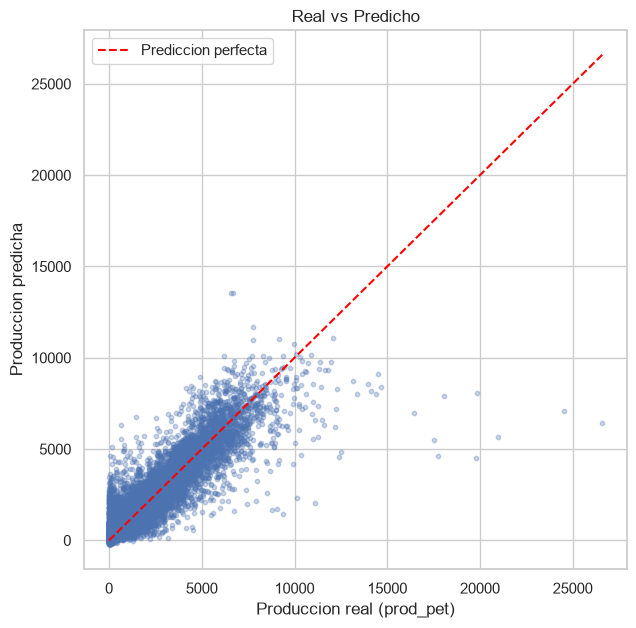

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predicciones, alpha=0.3, s=10)

valor_max = max(y_test.max(), predicciones.max())
plt.plot([0, valor_max], [0, valor_max], color="red", linestyle="--", label="Prediccion perfecta")

plt.xlabel("Produccion real (prod_pet)")
plt.ylabel("Produccion predicha")
plt.title("Real vs Predicho")
plt.legend()
plt.show()

## Paso 8: Que variables usa mas el modelo (importancia de features)

Nos muestra que tan importante fue cada variable para las predicciones
del modelo. Es un primer acercamiento a la explicabilidad - mas adelante
se puede profundizar con SHAP.

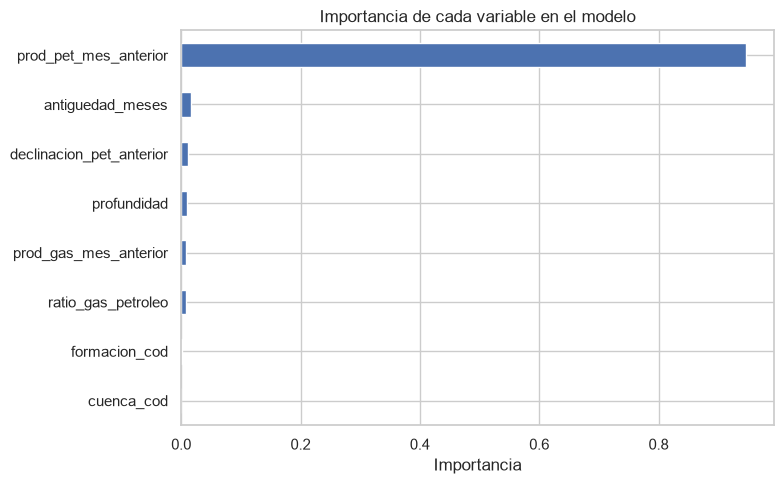

In [12]:
importancias = pd.Series(modelo.feature_importances_, index=columnas_features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="#4C72B0")
plt.title("Importancia de cada variable en el modelo")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### Zoom en los valores altos

En el modelo base, los pozos con produccion muy alta (picos) quedaban
subestimados. Miramos ese mismo rango ahora, para ver si mejoro.

In [13]:
umbral_alto = 10000  # mismo corte que usamos para detectar el problema antes

alta_produccion = y_test > umbral_alto
print("Cantidad de meses con produccion real > 10.000:", alta_produccion.sum())

if alta_produccion.sum() > 0:
    error_promedio_alto = (y_test[alta_produccion] - predicciones[alta_produccion]).mean()
    print(f"Error promedio en esos casos (real - predicho): {error_promedio_alto:.1f}")
    print("Referencia (+ maxima historica, descartado): 4843.2")
    print("Referencia (log-transform, descartado): 6028.6 (sobreestimaba, no subestimaba)")

Cantidad de meses con produccion real > 10.000: 60
Error promedio en esos casos (real - predicho): 5153.7
Referencia (+ maxima historica, descartado): 4843.2
Referencia (log-transform, descartado): 6028.6 (sobreestimaba, no subestimaba)


## Paso 9: Comparar con LightGBM

La consigna original del proyecto pide entrenar y **comparar** modelos de
regresion (XGBoost y LightGBM), no quedarse con uno solo. Entrenamos
LightGBM con las mismas 8 features, el mismo split por anio, y parametros
equivalentes, para que la comparacion sea justa (misma info, mismas
reglas de juego).

In [14]:
modelo_lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
)

modelo_lgbm.fit(X_train, y_train)
print("Modelo LightGBM entrenado")

Modelo LightGBM entrenado


In [15]:
predicciones_lgbm = modelo_lgbm.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, predicciones_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, predicciones_lgbm))
r2_lgbm = r2_score(y_test, predicciones_lgbm)

print(f"MAE:  {mae_lgbm:.2f}")
print(f"RMSE: {rmse_lgbm:.2f}")
print(f"R2:   {r2_lgbm:.3f}")

MAE:  163.86
RMSE: 439.34
R2:   0.888


### Tabla comparativa: XGBoost vs LightGBM

Mismos datos, mismas features, mismo split - la diferencia es solo el
algoritmo.

In [16]:
comparacion_modelos = pd.DataFrame({
    "XGBoost": [round(mae, 2), round(rmse, 2), round(r2, 3)],
    "LightGBM": [round(mae_lgbm, 2), round(rmse_lgbm, 2), round(r2_lgbm, 3)],
}, index=["MAE", "RMSE", "R2"])

comparacion_modelos

,XGBoost,LightGBM
MAE,163.330,163.860
RMSE,445.420,439.340
R2,0.885,0.888


### Chequeo en valores altos (>10.000) - LightGBM

Miramos si LightGBM tiene el mismo problema de subestimar los picos, o
si le va distinto a XGBoost en ese aspecto puntual.

In [17]:
error_promedio_alto_lgbm = (y_test[alta_produccion] - predicciones_lgbm[alta_produccion]).mean()
print(f"Error promedio en picos altos (LightGBM): {error_promedio_alto_lgbm:.1f}")
print(f"Error promedio en picos altos (XGBoost, referencia): {error_promedio_alto:.1f}")

Error promedio en picos altos (LightGBM): 4998.2
Error promedio en picos altos (XGBoost, referencia): 5153.7


### Importancia de variables - LightGBM

Comparamos si LightGBM le da importancia a las mismas variables que
XGBoost, o si "opina" distinto sobre cuales son las mas relevantes.

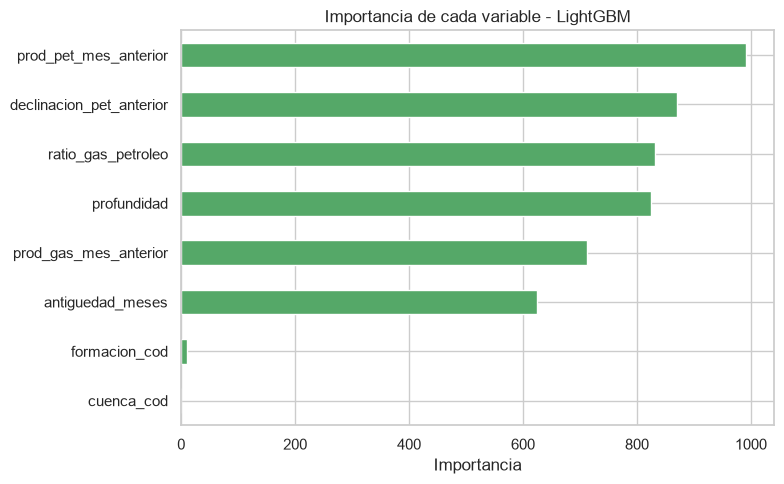

In [18]:
importancias_lgbm = pd.Series(modelo_lgbm.feature_importances_, index=columnas_features)
importancias_lgbm = importancias_lgbm.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias_lgbm.plot(kind="barh", color="#55A868")
plt.title("Importancia de cada variable - LightGBM")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## Paso 10: Guardar el modelo entrenado (version FINAL de esta etapa)

Lo guardamos en `models/` para poder usarlo despues en la API
(`api/app.py`) sin tener que reentrenarlo cada vez. Guardamos AMBOS
modelos (XGBoost y LightGBM), y dejamos marcado cual es el principal
segun el resultado de la comparacion de arriba - completar la variable
`mejor_modelo` despues de ver la tabla comparativa.

In [19]:
os.makedirs("models", exist_ok=True)

joblib.dump(modelo, "models/modelo_produccion_pet_xgboost.joblib")
joblib.dump(modelo_lgbm, "models/modelo_produccion_pet_lightgbm.joblib")

# Cambiar aca segun cual dio mejor resultado en la tabla comparativa
mejor_modelo = modelo_lgbm  # o modelo_lgbm
joblib.dump(mejor_modelo, "models/modelo_produccion_pet.joblib")

print("Modelos guardados: xgboost, lightgbm, y el principal (modelo_produccion_pet.joblib)")

Modelos guardados: xgboost, lightgbm, y el principal (modelo_produccion_pet.joblib)


## Conclusiones

Se probaron 4 ajustes sobre el modelo base, documentando tanto los que
funcionaron como los que no:

1. **`declinacion_pet` (variacion respecto al mes actual):** parecia una
   mejora enorme (R2 0.978), pero se detecto **fuga de datos** - la
   formula de esa variable contenia `prod_pet`, lo que el modelo debia
   predecir. Se corrigio usando `declinacion_pet_anterior` (informacion
   solo del pasado), logrando una mejora real y modesta: R2 0.885 vs
   0.853 del modelo base.
2. **`prod_pet_maxima_anterior` (maximo historico del pozo):** no aporto
   mejora real (mismo R2, MAE levemente peor) y el grafico de
   importancias mostro que el modelo casi no la uso. Descartada.
3. **Log-transform (`log(1 + prod_pet)`):** en vez de agregar otra
   variable, se probo cambiar la forma de entrenar. Resultado: empeoro
   todo (RMSE subio a 501.67, R2 bajo a 0.854) y genero un problema
   nuevo y mas grave - sobreestimaciones extremas (hasta 35.000 para
   pozos que producian 7.000-10.000 reales), por la amplificacion que
   sufre el error al revertir el logaritmo. Descartada.
4. **Modelo final:** el modelo base + `declinacion_pet_anterior` (8
   features), entrenado directo sobre `prod_pet`, resulto ser la mejor
   combinacion de metricas con la menor complejidad de todo lo probado.
5. **Comparacion XGBoost vs LightGBM** (tal como pide la consigna
   original): se entreno LightGBM con las mismas 8 features y el mismo
   split, y se comparo cara a cara contra XGBoost - ver la tabla y el
   chequeo de picos altos en el Paso 9. Completar esta conclusion con
   cual de los dos dio mejor resultado una vez corrido el notebook.

**Limitacion conocida (aceptada):** en todas las versiones validas, el
modelo subestima los pozos con picos de produccion muy altos (posibles
reestimulaciones/refracturas). Se probaron dos enfoques distintos para
resolverlo (una variable nueva y un cambio de objetivo de entrenamiento)
y ninguno funciono. Esto sugiere que el problema no es de ingenieria de
datos sobre lo que ya tenemos, sino de **falta de una variable que el
dataset no incluye** (por ejemplo, si se programo o no una intervencion
en el pozo), no solo mas ingenieria sobre los datos que ya tenemos.

**Comparacion XGBoost vs LightGBM (Paso 10):** se entreno un segundo
modelo con LightGBM, mismas features y mismo split, para cumplir con el
objetivo de la propuesta original de comparar ambos algoritmos. La tabla
comparativa y el chequeo de picos altos (arriba) muestran si alguno de
los dos maneja mejor los valores extremos, o si el problema persiste por
igual en ambos (lo cual reforzaria la hipotesis de que el problema es de
falta de informacion, no del algoritmo elegido).

**Proximo paso:** `04_modelado_no_supervisado_dl.ipynb` - agrupar pozos
segun su curva de produccion usando K-Means. Los pozos con picos que el
modelo supervisado no logra predecir bien son candidatos interesantes
para revisar como un grupo aparte en el clustering.